<a href="https://colab.research.google.com/github/sairamaiml/Lab-Manual/blob/main/DL%20EXP%203.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install idx2numpy

  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7903 sha256=57fc04fae3e822ead62ef2fb123add566f12437bda1a433faa92efff2fc719a3
  Stored in directory: /root/.cache/pip/wheels/f7/48/00/ae031c97d62f39e1c3c4daa00426c09a65eb29ae5753a189ee
Successfully built idx2numpy


100%|██████████| 1.24G/1.24G [00:11<00:00, 114MB/s]

Extracting files...


Training Images : (112800, 28, 28)
Training Labels : (112800,)
Testing Images  : (18800, 28, 28)
Testing Labels  : (18800,)
Classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]
Number of classes: 47


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 47)             │         6,063 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,807 (897.68 KB)

 Trainable params: 229,807 (897.68 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/4
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.6263 - loss: 1.2593 - val_accuracy: 0.8256 - val_loss: 0.5146
Epoch 2/4
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7718 - loss: 0.7047 - val_accuracy: 0.8487 - val_loss: 0.4338
Epoch 3/4
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8019 - loss: 0.6028 - val_accuracy: 0.8574 - val_loss: 0.3982
Epoch 4/4
1410/1410 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8187 - loss: 0.5434 - val_accuracy: 0.8648 - val_loss: 0.3817
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8654 - loss: 0.3963

Test Loss : 0.3962600529193878
Test Accuracy : 0.865372359752655


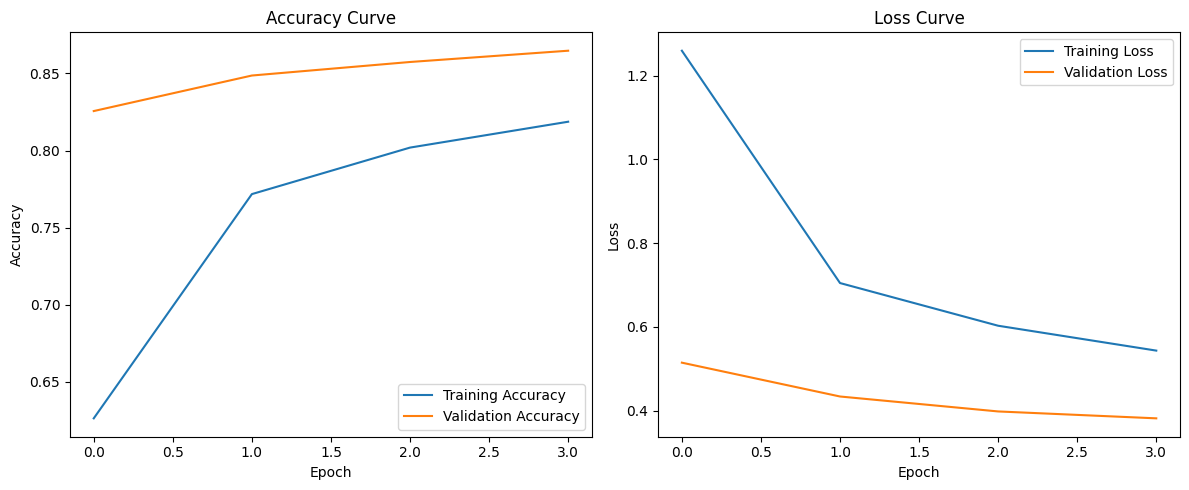

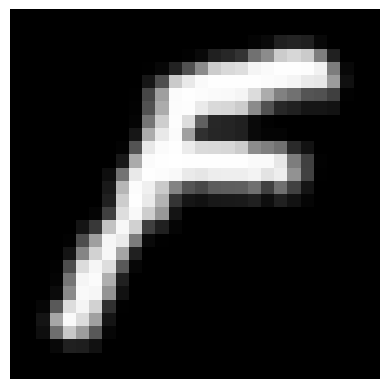

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
Actual Character   : f
Predicted Character: F
Confidence         : 70.38 %


In [4]:
import os
import kagglehub
import idx2numpy
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Download dataset
dataset_path = kagglehub.dataset_download("crawford/emnist")

# Fix: Account for the subfolder where ubyte files are stored
ubyte_dir = os.path.join(dataset_path, "emnist_source_files")
if not os.path.exists(ubyte_dir):
    ubyte_dir = dataset_path  # Fallback if structure varies

train_images_path = os.path.join(ubyte_dir, "emnist-balanced-train-images-idx3-ubyte")
train_labels_path = os.path.join(ubyte_dir, "emnist-balanced-train-labels-idx1-ubyte")
test_images_path  = os.path.join(ubyte_dir, "emnist-balanced-test-images-idx3-ubyte")
test_labels_path  = os.path.join(ubyte_dir, "emnist-balanced-test-labels-idx1-ubyte")

# Load raw dataset arrays
x_train = idx2numpy.convert_from_file(train_images_path)
y_train = idx2numpy.convert_from_file(train_labels_path)
x_test  = idx2numpy.convert_from_file(test_images_path)
y_test  = idx2numpy.convert_from_file(test_labels_path)

# Fix: Rotate and transpose raw EMNIST images so characters render right-side up
x_train = np.array([np.rot90(np.fliplr(img)) for img in x_train])
x_test = np.array([np.rot90(np.fliplr(img)) for img in x_test])

print("Training Images :", x_train.shape)
print("Training Labels :", y_train.shape)
print("Testing Images  :", x_test.shape)
print("Testing Labels  :", y_test.shape)

# Normalize & reshape for Keras CNN
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print("Classes:", np.unique(y_train))
print("Number of classes:", len(np.unique(y_train)))

# 2. Build and compile the CNN
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(47, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 3. Train
history = model.fit(
    x_train,
    y_train,
    epochs=4,
    batch_size=64,
    validation_split=0.2
)

# 4. Evaluate
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("\nTest Loss :", test_loss)
print("Test Accuracy :", test_accuracy)

# Plot accuracy and loss curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# 5. Mapping ASCII characters & Test Prediction
mapping = {}
mapping_file_path = os.path.join(dataset_path, "emnist-balanced-mapping.txt")

with open(mapping_file_path, "r") as f:
    for line in f:
        label, ascii_code = line.split()
        mapping[int(label)] = chr(int(ascii_code))

index = 25
# Reshape sample image from (28, 28, 1) to (28, 28) for display
sample_image = x_test[index].reshape(28, 28)
label = y_test[index]

plt.imshow(sample_image, cmap="gray")
plt.axis("off")
plt.show()

# Expand dimensions to (1, 28, 28, 1) for prediction
prediction = model.predict(np.expand_dims(x_test[index], axis=0))
predicted_label = np.argmax(prediction)

print("Actual Character   :", mapping[label])
print("Predicted Character:", mapping[predicted_label])
print("Confidence         :", round(float(np.max(prediction)) * 100, 2), "%")
